# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d.frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.preprocess_vis import Gridding
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = AS209

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']


data_file = dir +"uvtable_" + disk_name + "_continuum.npz"
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']

#data_file2 = dir + "AS209_continuum_prom_1chan_30s_keepflagsFalse.txt"
#file = np.loadtxt(data_file2)
#u, v, Re, Im, Weights = file[:,0], file[:,1], file[:,2], file[:,3], file[:,4]

In [8]:
 # load data
Vis = Re + Im*1j

In [9]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

# F2D

### Run

In [10]:
# Frank Parameters
N = 300
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [11]:
frank2d.process_vis(uvtable)

Setting gridded data...


Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.05  min |  3.13 seconds
--> time = 0.05  min |  3.25 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.8817519827904894
Final tolerance :  2.8817519827904894
.... iteration:  0
                        -> actual tol:  288175198.2790489 vs  2.8817519827904894
.... iteration:  1
                        -> actual tol:  39773051.28293856 vs  2.8817519827904894
.... iteration:  2
                        -> actual tol:  30605898.285019003 vs  2.8817519827904894
.... iteration:  3
                        -> actual tol:  31458951.244817313 vs  2.8817519827904894
.... iteration:  4
                        -> actual tol:  32660086.131723378 vs  2.8817519827904894
.... iteration:  5
                        -> actual tol:  32037725.26407906 vs  2.8817519827904894
.... iteration:  6
                        -> actual tol:  68808904.85475662 vs  2.8817519827904894
.... iteration:  7
 

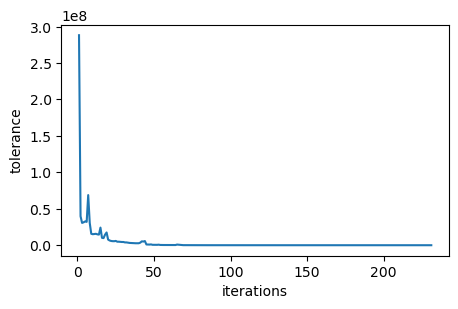

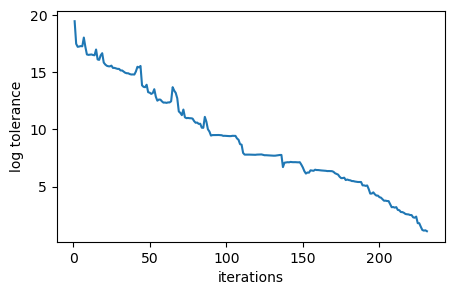

--> time = 0.15  min |  9.15 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 0.31 minutes.


In [12]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 7e4}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

## Plot

In [13]:
Plot_ = Plot(frank2d, geom)

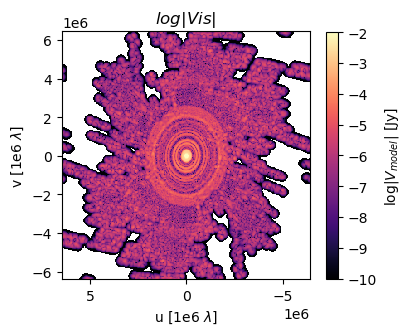

In [14]:
Plot_.visibility(fig_size = 4)

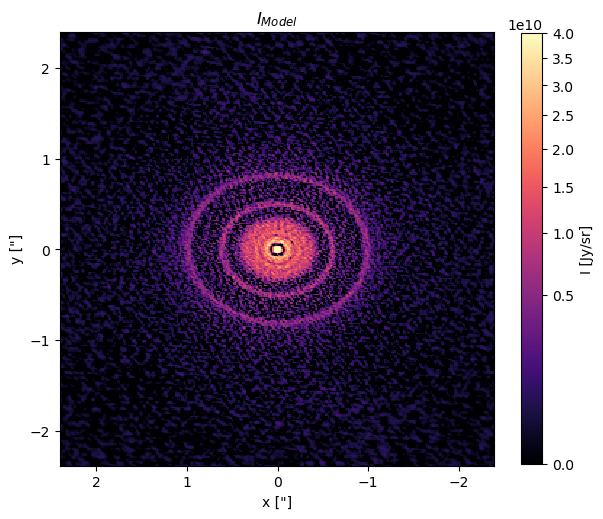

In [15]:
Plot_.intensity(fig_size = 7)

### Gridding for F1D

In [16]:
from scipy.stats import binned_statistic

In [17]:

u_ = frank2d.FT.u
v_ = frank2d.FT.v

u_grid = np.linspace(u_[0], u_[-1], 1000)
v_grid = np.linspace(v_[0], v_[-1], 1000)

Grid = Gridding(frank2d.Rmax, frank2d.FT, frank2d.Geometry)

Grid.set_bins(u_grid, v_grid)
u_f1d, v_f1d, vis_f1d, w_f1d  = Grid.run(uvtable['u'], uvtable['v'], uvtable['vis'], uvtable['weights'])

uvtable_f1d = {'u': u_f1d, 'v': v_f1d, 'vis': vis_f1d, 'weights': w_f1d}


# Plot

In [18]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
import matplotlib.colors as colors

# frank1d utilities
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

from frank2d.constants import rad_to_arcsec, deg_to_rad


from astropy.io import fits
from gofish import imagecube


### Class

In [19]:
class PlotTest(object):
    def __init__(self, Frank2D, Geometry):
        self._Frank2D = Frank2D
        self._Geometry = Geometry
        self._FT = Frank2D._FT
        self._Nx = self._Ny = Frank2D._N
        
        self._u_input = Frank2D._gridded_data['u']
        self._v_input = Frank2D._gridded_data['v']
        self._vis_input = Frank2D._gridded_data['vis']
        self._weights_input = Frank2D._gridded_data['weights']

        self._u_model = self._Frank2D.u_grid
        self._v_model = self._Frank2D.v_grid
        self._u_model_1d = self._Frank2D.u
        self._v_model_1d = self._Frank2D.v
        self._vis_model = Frank2D.visibility_model

        self._x_model = self._Frank2D.x_grid*rad_to_arcsec
        self._y_model = self._Frank2D.y_grid*rad_to_arcsec
        self._x_model_1d = self._Frank2D.x*rad_to_arcsec
        self._y_model_1d = self._Frank2D.y*rad_to_arcsec
        self._int_model = Frank2D.intensity_model.real

        self._int_model_shifted = None

        self._Rmax = Frank2D.Rmax

    def get_profile(self, x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
        from scipy.stats import binned_statistic
        
        if not fit_1d:
            r = np.hypot(x1, x2)
            r = r.ravel(order = 'C')
            f = f.ravel(order = 'C')
        else:
            r = x1

        if weighted:
            if weights is None:
                raise ValueError("Add weights.")
            weights_gridded = self._weights_input
            F_W_binned, bin_edges, _ = binned_statistic(r, f*weights_gridded, 'sum', bins = bins)
            Weights_binned, bin_edges, _ = binned_statistic(r, weights_gridded, 'sum', bins = bins)

            f_1d = np.nan_to_num(F_W_binned, nan=0)
            f_1d = f_1d/Weights_binned
        else:
            f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
        
        r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
            
        return r_1d, f_1d


    def edges(self, x):
        mids = (x[1:] + x[:-1]) / 2.0
        first = x[0]  - (x[1] - x[0]) / 2.0
        last  = x[-1] + (x[-1] - x[-2]) / 2.0
        return np.r_[first, mids, last]
    
    def calculate_resolution(self, clean_beam, intrinsic_resolution):
        bmaj_as = clean_beam['bmaj']
        bmin_as = clean_beam['bmin']
        final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
        final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
        print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
        final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
        return final_resolution

    def f1d_profile(self, data, params = None):
        if params is None:
            params = {'alpha': 1.2, 'w_smooth': 1e-3, 'rout': None}
        
        f2d = self._Frank2D
        u, v = data['u'], data['v']
        vis = data['vis']
        weights = data['weights']

        sol = f2d.frank1d(  u = u, v = v,
                            vis = vis, weights = weights,
                            alpha = params['alpha'],
                            w_smooth = params['w_smooth'],
                            rout = params['rout'],
                            n_pts = self._Nx
                        )
        
        self._f1d_profile = [ sol.r, sol.mean ]


        
    def intensity_profile(self, title= r'Brightness profile', 
                          clean = False, fits_file = None,
                          frank1d = True, f1d_data = None,
                          f1d_params = {'alpha': 1.2, 'w_smooth': 1e-3, 'rout': None},
                          bins = 300,
                          Rmax = None,
                          resol_f2d = 0,
                          resol_f1d = 0):
        f2d = self._Frank2D
        geom = self._Geometry
        inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

        beam_for_f2d = None
        beam_for_f1d = None

        if clean:
            if fits_file is None:
                raise ValueError("Data location for the FITS file to make the CLEAN profile is not provided.")
            else:
                cube_1mm = imagecube(fits_file)
                x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)
                
                fits_image = fits.open(fits_file)
                header = fits_image[0].header
                bmaj_deg = float(header["BMAJ"])
                bmin_deg = float(header["BMIN"])
                bmaj_as = bmaj_deg * 3600.0
                bmin_as = bmin_deg * 3600.0
                bpa_deg = header['BPA']
                
                clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
                clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
                print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

                # Decide the beam to convolve with.
                if resol_f2d > 0:
                    print(f"FWHM for frank2d: {resol_f2d} arcsec")
                    beam_for_f2d = self.calculate_resolution(clean_beam, resol_f2d)
                else: 
                    beam_for_f2d = clean_beam
                
                if resol_f1d > 0 and frank1d:
                    print(f"FWHM for frank1d: {resol_f1d} arcsec")
                    beam_for_f1d = self.calculate_resolution(clean_beam, resol_f1d)
                else:
                    beam_for_f1d = clean_beam


        # input
        u_input_g = self._u_input
        v_input_g = self._v_input
        vis_input_g = self._vis_input
        weights_input_g = self._weights_input

        # model
        u_model = self._u_model
        v_model = self._v_model
        vis_model = self._vis_model
        
        u_model_1d = self._u_model_1d
        v_model_1d = self._v_model_1d

        x_model = self._x_model
        y_model = self._y_model

        x_model_1d = self._x_model_1d
        y_model_1d = self._y_model_1d
        
        # phase shift
        vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
        I = f2d.transform(vis).real
        self._int_model_shifted = I

        # deproject
        x_model, y_model = geom.deproject_xy(x_model, y_model)
        x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

        # collocation points for the plot.
        r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
        r = np.linspace(r.min(), r.max(), bins)
        edges = self.edges(r)

        # f1d
        if frank1d:
            #frank1d
            if f1d_data is None:
                raise ValueError("Input data for frank1d not provided. Use the uvtable.")

            self.f1d_profile(f1d_data, params = f1d_params)

        r_model_1d, I_model_1d = self.get_profile(x_model, y_model, I, bins = edges)
        I_model_1d = np.nan_to_num(I_model_1d, nan=0)
        
        Rmax = self._Rmax/2 if Rmax is None else Rmax
        plt.figure(figsize=(10,4))
        if clean:
            area = clean_area
            #  CLEAN --------------------------------------------------------------------
            plt.plot(x_clean, y_clean, "black", label = "CLEAN")
            plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
            # frank2D -------------------------------------------------------------------
            I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
            I_model_1d_convolved *= area # Jy/beam
            plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')
            
            if frank1d:
                # frank1D ---------------------------------------------------------------
                I_f1d_convolved = convolve_profile(r_f1d, I_f1d, inc, pa, beam_for_f1d)
                I_f1d_convolved *= area # Jy/beam
                plt.plot(r_f1d, I_f1d_convolved, color = "red", label = r'frank1d')
        
            plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
            plt.xlabel('Radius ["]', size=10)
            plt.legend(fontsize=12)
            plt.yscale('log')
            plt.ylim(1e-6, 3e-3)
            plt.xlim(0, Rmax)
            plt.show()
        else:
            # frank1D -------------------------------------------------------------------
            if frank1d:
                r_f1d, I_f1d = self._f1d_profile
                plt.plot(r_f1d, I_f1d, color = "red", label = r'frank1d')
    
            # frank2D -------------------------------------------------------------------
            plt.plot(r_model_1d, I_model_1d, color = 'blue', ls ='--', label = r'frank2d')

            plt.xlabel('Radius ["]', size = 10)
            plt.ylabel(r'log($I_\nu$) [$10^{10}$ Jy sr$^{-1}$]', size = 10)
            plt.title(title)
            plt.xlim(0, Rmax)
            plt.yscale('log')
            plt.legend()
            plt.show()
    
    def intensity(self, title= r'$I_{Model}$', fig_size = 6, vmin = 0, vmax = 4e10, gamma = 0.45,
                  phase_shift = True, deproject = False):
        
        Nx, Ny = self._Nx, self._Ny
        f2d = self._Frank2D
        geom = self._Geometry
        
        I = self._int_model

        u_grid = self._u_model #(N, N)
        v_grid = self._v_model
        if phase_shift:
            # Only in this scheme (East of North) makes sense to do the phase shifting.
            vis_ = self._vis_model
            vis = geom.apply_phase_shift(-u_grid, -v_grid, vis_)
            I = f2d.transform(vis).real
        
        # The signs are because the convention: East of North.
        x = -self._x_model
        y = -self._y_model
        if deproject:
            xd, yd = geom.deproject_xy(x, y)
            x, y = xd, yd
            
        plt.figure(figsize = (fig_size, fig_size))
        norm = colors.PowerNorm(gamma = gamma, vmin = vmin, vmax = vmax)
        plt.pcolormesh(x,
                       y,
                       I,
                       cmap="magma",
                       norm=norm)
        plt.xlabel(r'x ["]')
        plt.ylabel(r'y ["]')
        cmap = plt.colorbar(shrink=0.8)
        plt.title(title)
        cmap.set_label(r'I [Jy/sr]', size=10)
        
        plt.xlim(x.max(), x.min())
        plt.ylim(y.max(), y.min())
        
        plt.gca().set_aspect(1)
        plt.gca().invert_yaxis()
        plt.show()

### Testing

In [20]:
Plot_ = Plot(frank2d, geom)

In [21]:
frank2d.N

300

In [22]:
rout 

2.4

In [23]:
sol_f1d = frank2d.frank1d(uvtable_f1d, alpha=1.2, w_smooth=1e-3, n_pts=300, rout=rout, geom=geom)

Performing 1D Frank fit...

$\alpha$ =  1.2  and $w_{smooth}$ =  0.001

N =  300  and $R_{max}$ =  2.4


In [24]:
Plot_.set_f1d_solution(sol_f1d)

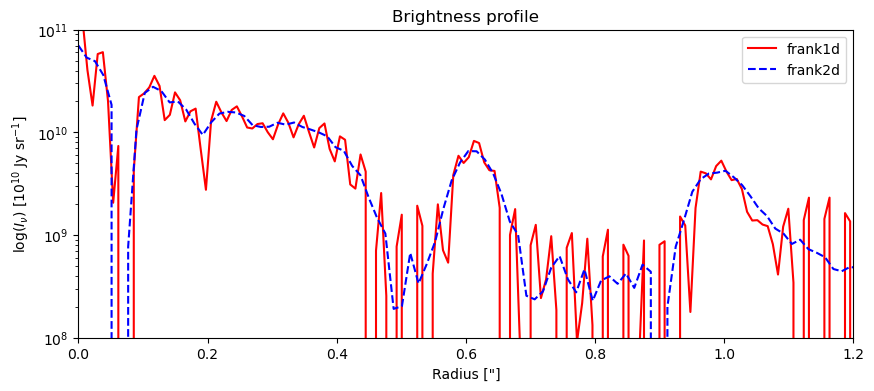

In [25]:
Plot_.intensity_profile(clean = False, frank1d = True, x_lims=(0, 1.2))